Indexing volumes...
Indexing volumes...


I0000 00:00:1774898798.973467      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774898798.979608      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


🚀 Training weak 3D U-Net...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3


I0000 00:00:1774898815.299628     131 service.cc:152] XLA service 0x7d803c04f060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774898815.299676     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774898815.299682     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774898815.830075     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/112 ━━━━━━━━━━━━━━━━━━━━ 19:38 11s/step - accuracy: 0.7500 - loss: 0.6713

I0000 00:00:1774898819.578699     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


112/112 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.4558 - loss: 0.6811 - val_accuracy: 0.5000 - val_loss: 0.6718
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 62s 552ms/step - accuracy: 0.5212 - loss: 0.6579 - val_accuracy: 0.5000 - val_loss: 0.6474
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 488ms/step - accuracy: 0.4908 - loss: 0.6497 - val_accuracy: 0.5439 - val_loss: 0.6306


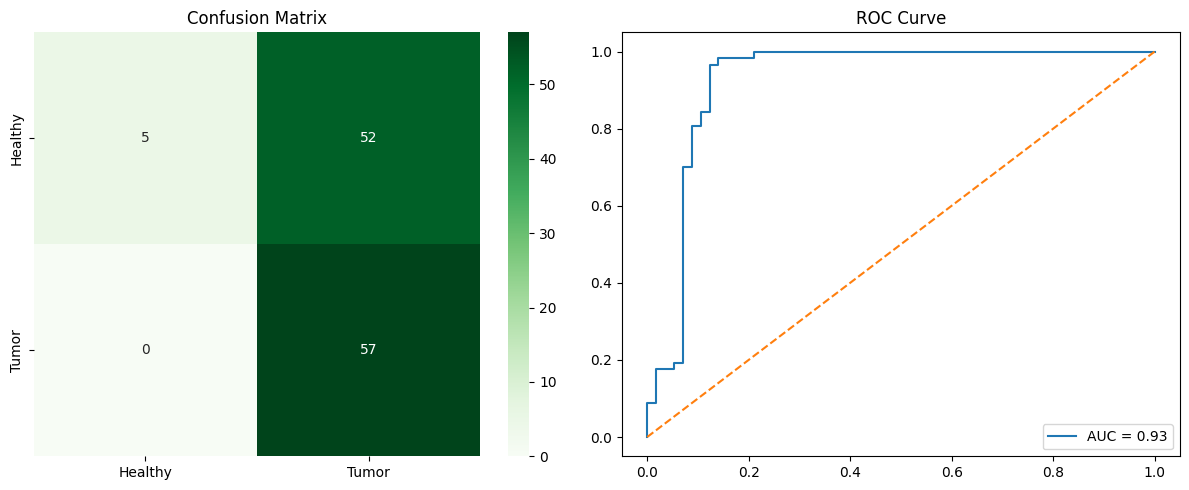

              precision    recall  f1-score   support

           0       1.00      0.09      0.16        57
           1       0.52      1.00      0.69        57

    accuracy                           0.54       114
   macro avg       0.76      0.54      0.42       114
weighted avg       0.76      0.54      0.42       114

AUC: 0.9277


In [3]:
# ================= IMPORTS =================
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Conv3DTranspose, concatenate, GlobalAveragePooling3D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ================= CONFIG =================
PATCH_SIZE = 64
BATCH_SIZE = 4
EPOCHS = 3   # ↓ reduced

BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# ================= DATA SEQUENCE =================
class WeakPancreas3DSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.samples = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        print("Indexing volumes...")

        for file in self.patient_files:
            if file.startswith("._"):
                continue

            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path):
                continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2)

            if len(tumor_indices) > 0:
                tumor_center = tumor_indices[np.random.randint(len(tumor_indices))]
                samples.append((file, tumor_center, 1))

                h, w, d = mask_vol.shape
                while True:
                    pt = [np.random.randint(0,h), np.random.randint(0,w), np.random.randint(0,d)]
                    if mask_vol[tuple(pt)] == 0:
                        break
                samples.append((file, pt, 0))

        np.random.shuffle(samples)
        return samples

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []

        for file, center, label in batch:
            img_vol = nib.load(os.path.join(IMAGE_DIR, file)).get_fdata()
            z, yc, x = [int(c) for c in center]

            z_s, y_s, x_s = max(0,z-32), max(0,yc-32), max(0,x-32)
            patch = img_vol[z_s:z_s+64, y_s:y_s+64, x_s:x_s+64]

            if patch.shape != (64,64,64):
                patch = np.pad(patch, [(0,64-s) for s in patch.shape])

            # Normalize
            patch = np.clip(patch, -100, 200)
            patch = (patch + 100) / 300.0

            # 🔻 ADD NOISE (important)
            noise = np.random.normal(0, 0.05, patch.shape)
            patch = np.clip(patch + noise, 0, 1)

            X.append(patch[..., np.newaxis])
            y.append(label)

        return np.array(X), np.array(y)

# ================= WEAK 3D UNET =================
def build_weak_unet():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 1))

    c1 = Conv3D(8, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling3D(2)(c1)

    c2 = Conv3D(16, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling3D(2)(c2)

    b = Conv3D(32, 3, activation='relu', padding='same')(p2)

    u1 = Conv3DTranspose(16, 2, strides=2, padding='same')(b)
    u1 = concatenate([u1, c2])

    gap = GlobalAveragePooling3D()(u1)

    dense = Dense(32, activation='relu')(gap)

    # 🔻 stronger dropout
    drop = Dropout(0.6)(dense)

    output = Dense(1, activation='sigmoid')(drop)

    model = Model(inputs, output)
    model.compile(
        optimizer=Adam(5e-5),   # slower learning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ================= LOAD DATA =================
all_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith((".nii",".nii.gz")) and not f.startswith(".")
])

train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)

train_seq = WeakPancreas3DSequence(train_f)
test_seq = WeakPancreas3DSequence(test_f)

# ================= TRAIN =================
model = build_weak_unet()
print("🚀 Training weak 3D U-Net...")
model.fit(train_seq, validation_data=test_seq, epochs=EPOCHS)

# ================= EVALUATION =================
y_true, y_probs = [], []

for i in range(len(test_seq)):
    xb, yb = test_seq[i]
    preds = model.predict(xb, verbose=0)
    y_true.extend(yb)
    y_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# ================= METRICS =================
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_true, y_pred)

# ================= PLOTS =================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy','Tumor'],
            yticklabels=['Healthy','Tumor'])
plt.title('Confusion Matrix')

plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title('ROC Curve')

plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred))
print(f"AUC: {roc_auc:.4f}")